# PCA Dimensionality Reduction

U ovom notebook-u primenjujemo Principal Component Analysis (PCA) nad prethodno
preprocesiranim skupom podataka.  
Cilj je redukcija dimenzionalnosti feature prostora
uz zadržavanje većine varijanse podataka.

Dobijeni PCA transformisani skup biće korišćen za treniranje svih klasifikacionih
modela i poređenje sa modelima treniranim nad originalnim feature prostorom.

In [9]:
import numpy as np
from pathlib import Path

data_path = Path("../../data/processed/preprocessed.npz")
data = np.load(data_path, allow_pickle = True)

X_train = data["X_train"]
X_test = data["X_test"]

y_train = data["y_train"]
y_test = data["y_test"]

font_train = data["font_train"]
strength_train = data["strength_train"]
italic_train = data["italic_train"]

font_test = data["font_test"]
strength_test = data["strength_test"]
italic_test = data["italic_test"]

print("X_train shape:", X_train.shape)

X_train shape: (666136, 400)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.astype(np.float32))
X_test_scaled = scaler.transform(X_test.astype(np.float32))

In [11]:
from sklearn.decomposition import PCA

pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original dimension: ", X_train.shape)
print("Reduced dimension: ", X_train_pca.shape)

Original dimension:  (666136, 400)
Reduced dimension:  (666136, 400)


In [12]:
import numpy as np

explained_variance = np.cumsum(pca.explained_variance_ratio_)

print(explained_variance)


[0.14980441 0.24243203 0.2933938  0.33862862 0.38150886 0.4225731
 0.45691416 0.48888016 0.51434034 0.5387602  0.5612728  0.58216876
 0.6008936  0.6186439  0.6350097  0.649541   0.66283655 0.6755658
 0.6877007  0.6995057  0.71019053 0.7204671  0.73020375 0.7394756
 0.7479126  0.7556067  0.76295817 0.7701767  0.7773135  0.78405964
 0.789881   0.79535645 0.800633   0.8057103  0.8105672  0.81526875
 0.8196254  0.8239524  0.82805043 0.8319906  0.8358424  0.83956844
 0.843088   0.84645694 0.849772   0.8530432  0.8561475  0.8591265
 0.8619421  0.86467344 0.8674032  0.86999506 0.8724373  0.8748194
 0.87714285 0.87939525 0.88156825 0.88368905 0.8857562  0.88774884
 0.8896684  0.8915722  0.8934007  0.89517874 0.8969243  0.8986309
 0.90029943 0.9018487  0.9033476  0.9048118  0.90624774 0.9076538
 0.90905225 0.9104316  0.9117459  0.91303885 0.9142645  0.9154823
 0.91668564 0.9178719  0.9190475  0.92019075 0.921316   0.9224226
 0.9235163  0.9245858  0.9256431  0.9266691  0.92766964 0.92865086
 0.9

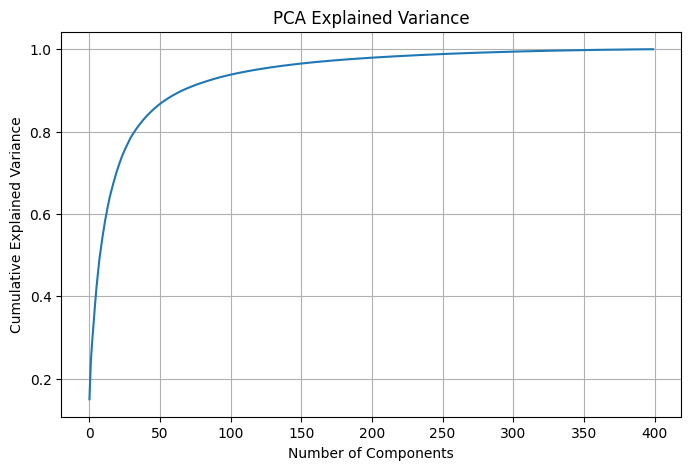

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [14]:
# trazimo indeks od kog je explained_variance >= 0.95 -> toliko komponenti nam treba na kraju
n95 = np.argmax(explained_variance >= 0.95) + 1
print("\nComponents for 95% variance: ", n95)


Components for 95% variance:  119


In [15]:
pca = PCA(n_components = n95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train.shape)
print("PCA shape:", X_train_pca.shape)

Original shape: (666136, 400)
PCA shape: (666136, 119)


In [16]:
output_path = "../../data/processed/pca_preprocessed.npz"

np.savez_compressed(
    output_path,
    X_train=X_train_pca,
    X_test=X_test_pca,
    y_train=y_train,
    y_test=y_test,
    font_train=font_train,
    font_test=font_test,
    strength_train=strength_train,
    strength_test=strength_test,
    italic_train=italic_train,
    italic_test=italic_test
)

print("PCA dataset saved.")

PCA dataset saved.
